In [1]:
import boto3
import pandas as pd
import time
import io

# Query Athena and return results as a pandas DataFrame
def query_athena(query, database='fx_rates_db', region='us-east-2'):
    athena = boto3.client('athena', region_name=region)
    s3 = boto3.client('s3', region_name=region)
    
    output_location = 's3://fx-rates-ninpar/athena-results/'
    
    response = athena.start_query_execution(
        QueryString=query,
        QueryExecutionContext={'Database': database},
        ResultConfiguration={'OutputLocation': output_location}
    )
    query_id = response['QueryExecutionId']
    
    # Wait for query to complete
    while True:
        status = athena.get_query_execution(QueryExecutionId=query_id)
        state = status['QueryExecution']['Status']['State']
        if state in ['SUCCEEDED', 'FAILED', 'CANCELLED']:
            break
        time.sleep(1)
    
    if state != 'SUCCEEDED':
        raise Exception(f"Query failed: {status['QueryExecution']['Status'].get('StateChangeReason')}")
    
    # Get the result file from S3
    result_location = status['QueryExecution']['ResultConfiguration']['OutputLocation']
    bucket = result_location.split('/')[2]
    key = '/'.join(result_location.split('/')[3:])
    
    obj = s3.get_object(Bucket=bucket, Key=key)
    df = pd.read_csv(io.BytesIO(obj['Body'].read()))
    
    return df

print("Athena query function ready")

Athena query function ready


In [7]:
df = query_athena("""
    SELECT date, 
           rates.inr AS usd_inr, 
           rates.eur AS usd_eur, 
           rates.gbp AS usd_gbp,
           rates.mxn AS usd_mxn,
           rates.php AS usd_php
    FROM fx_rates_db.usd
    ORDER BY date ASC
""")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

print(f"Loaded {len(df)} trading days")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nLatest rates:")
print(df.tail())

Loaded 279 trading days
Date range: 2025-04-29 00:00:00 to 2026-06-02 00:00:00

Latest rates:
            usd_inr  usd_eur  usd_gbp  usd_mxn  usd_php
date                                                   
2026-05-27    95.69  0.85933  0.74433  17.3189   61.455
2026-05-28    95.70  0.86081  0.74602  17.3883   61.556
2026-05-29    95.00  0.85881  0.74479  17.3394   61.572
2026-06-01    94.99  0.85866  0.74268  17.3270   61.752
2026-06-02    95.27  0.85844  0.74225  17.2830   61.664


In [8]:
import numpy as np

returns = df.pct_change().dropna()

comparison = pd.DataFrame({
    'avg_daily_return': returns.mean(),
    'daily_volatility': returns.std(),
    'annualized_vol': returns.std() * np.sqrt(252),
    'signal_to_noise': returns.mean().abs() / returns.std(),
    'sharpe_annual': (returns.mean() / returns.std()) * np.sqrt(252),
    'trend_direction': ['depreciation' if r > 0 else 'appreciation' 
                        for r in returns.mean()]
})

print("=== Currency Pair Comparison ===\n")
print(comparison.round(6).to_string())

print("\nInterpretation:")
print("Higher |Sharpe| = stronger trend relative to noise = potentially more forecastable")
print("Higher volatility = wider Bollinger bands = more room for signals")

=== Currency Pair Comparison ===

         avg_daily_return  daily_volatility  annualized_vol  signal_to_noise  sharpe_annual trend_direction
usd_inr          0.000412          0.003230        0.051271         0.127702       2.027204    depreciation
usd_eur         -0.000021          0.003834        0.060866         0.005545      -0.088028    appreciation
usd_gbp          0.000039          0.004305        0.068346         0.008967       0.142347    depreciation
usd_mxn         -0.000360          0.004925        0.078181         0.073195      -1.161934    appreciation
usd_php          0.000381          0.004217        0.066944         0.090335       1.434025    depreciation

Interpretation:
Higher |Sharpe| = stronger trend relative to noise = potentially more forecastable
Higher volatility = wider Bollinger bands = more room for signals


FileNotFoundError: [Errno 2] No such file or directory: 'notebooks/fx_rate_history.png'

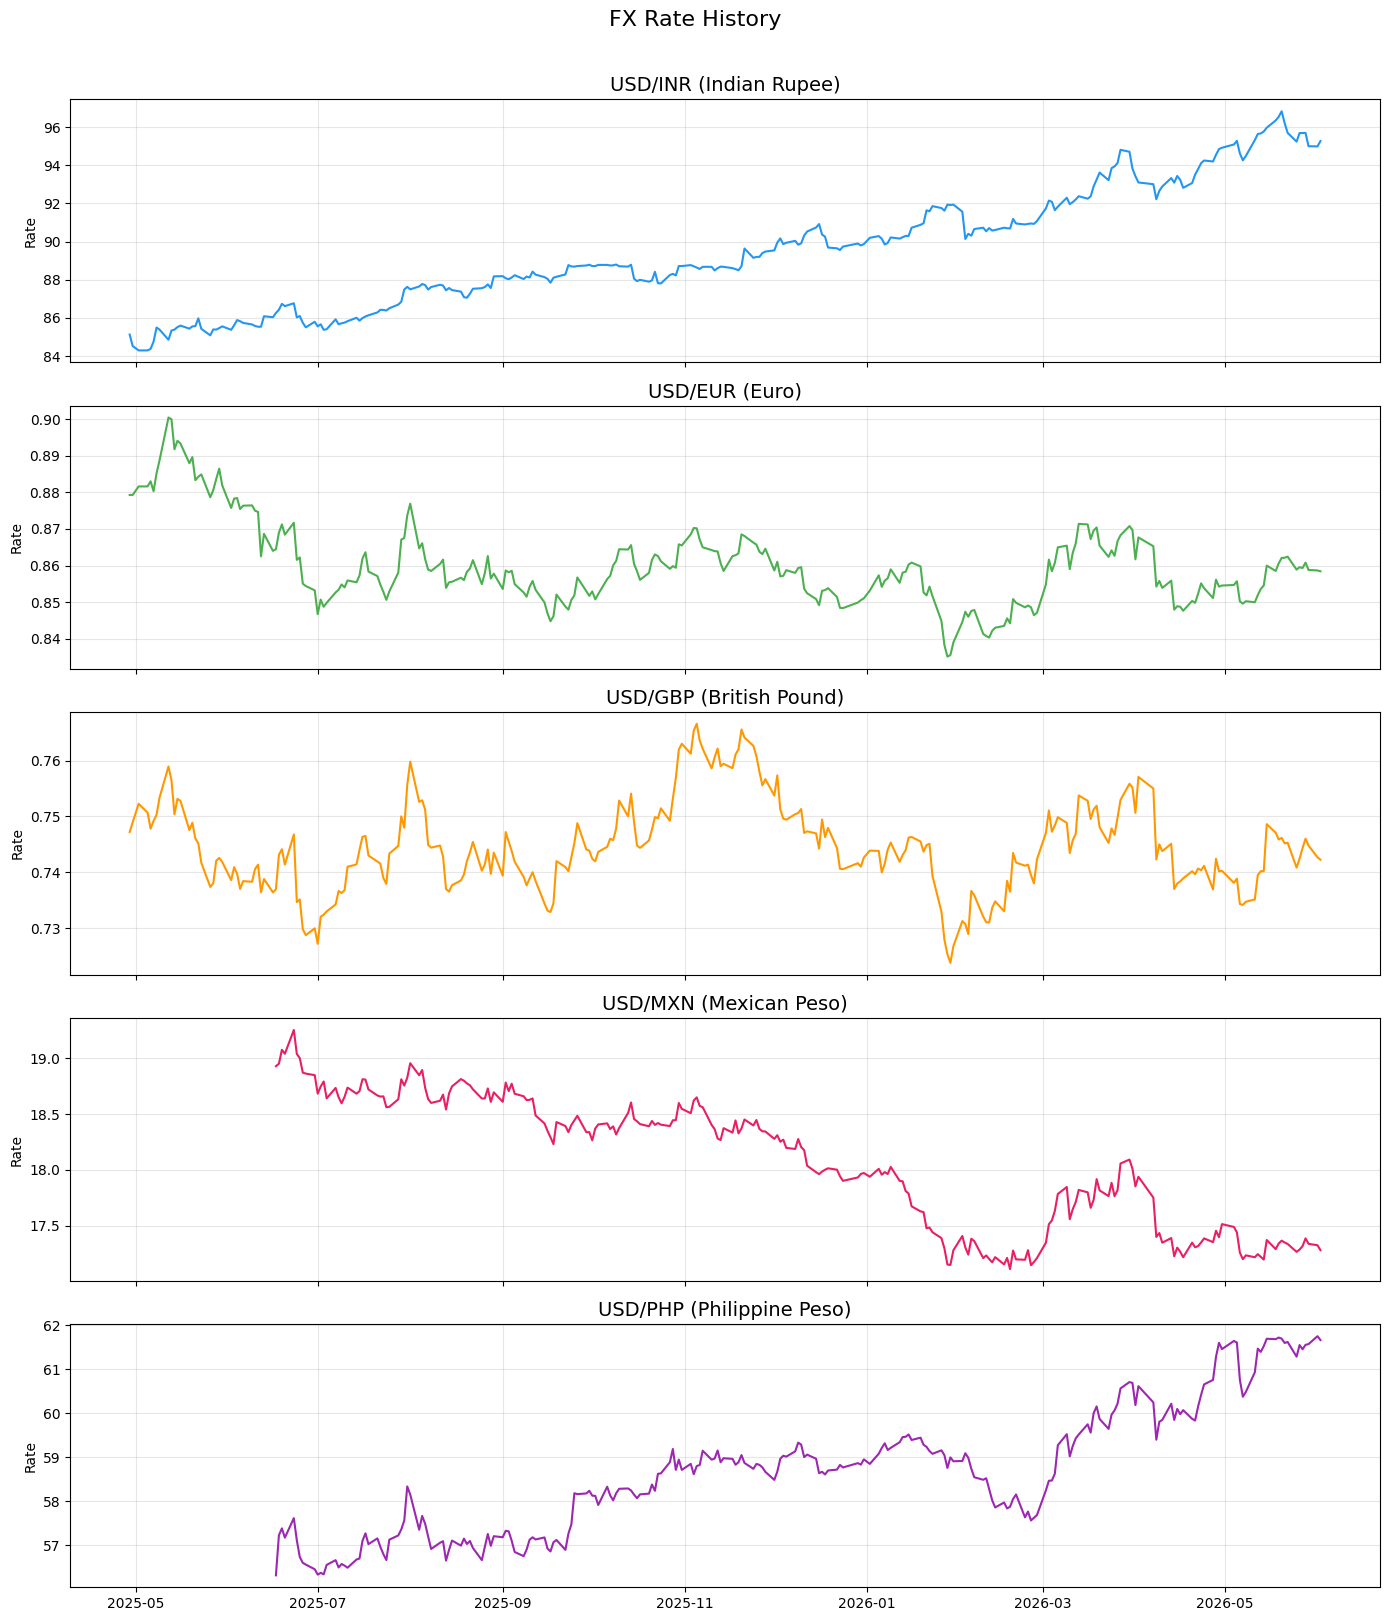

In [10]:
import matplotlib.pyplot as plt

currencies = {
    'usd_inr': ('#2196F3', 'USD/INR (Indian Rupee)'),
    'usd_eur': ('#4CAF50', 'USD/EUR (Euro)'),
    'usd_gbp': ('#FF9800', 'USD/GBP (British Pound)'),
    'usd_mxn': ('#E91E63', 'USD/MXN (Mexican Peso)'),
    'usd_php': ('#9C27B0', 'USD/PHP (Philippine Peso)')
}

fig, axes = plt.subplots(len(currencies), 1, figsize=(14, 16), sharex=True)

for i, (col, (color, title)) in enumerate(currencies.items()):
    axes[i].plot(df.index, df[col], color=color, linewidth=1.5)
    axes[i].set_title(title, fontsize=14)
    axes[i].set_ylabel('Rate')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('FX Rate History', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('notebooks/fx_rate_history.png', dpi=150, bbox_inches='tight')
plt.show()

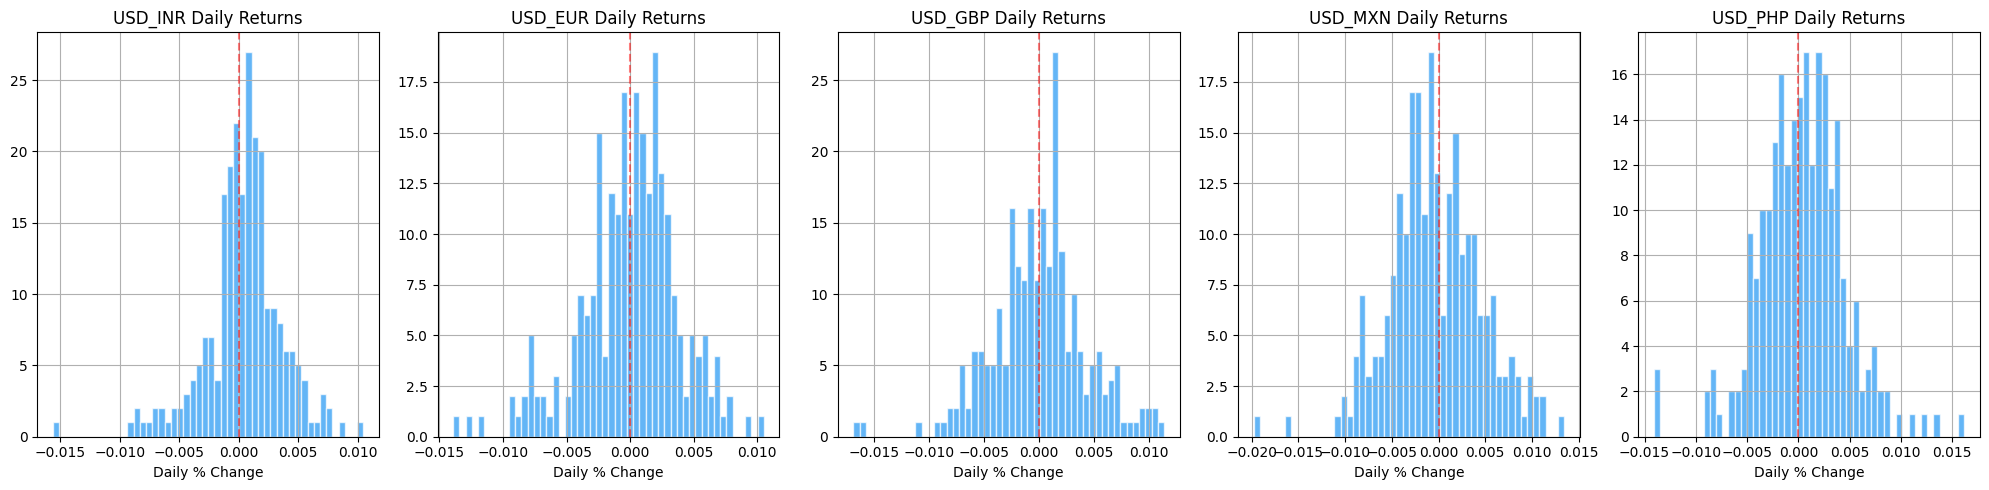

If the distribution is centered near zero and roughly symmetric,
that's consistent with near-random-walk behavior — hard to predict direction.


In [12]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(['usd_inr', 'usd_eur', 'usd_gbp','usd_mxn','usd_php']):
    returns[col].hist(bins=50, ax=axes[i], color='#2196F3', alpha=0.7, edgecolor='white')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(f'{col.upper()} Daily Returns')
    axes[i].set_xlabel('Daily % Change')

plt.tight_layout()
plt.savefig('fx_returns_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("If the distribution is centered near zero and roughly symmetric,")
print("that's consistent with near-random-walk behavior — hard to predict direction.")

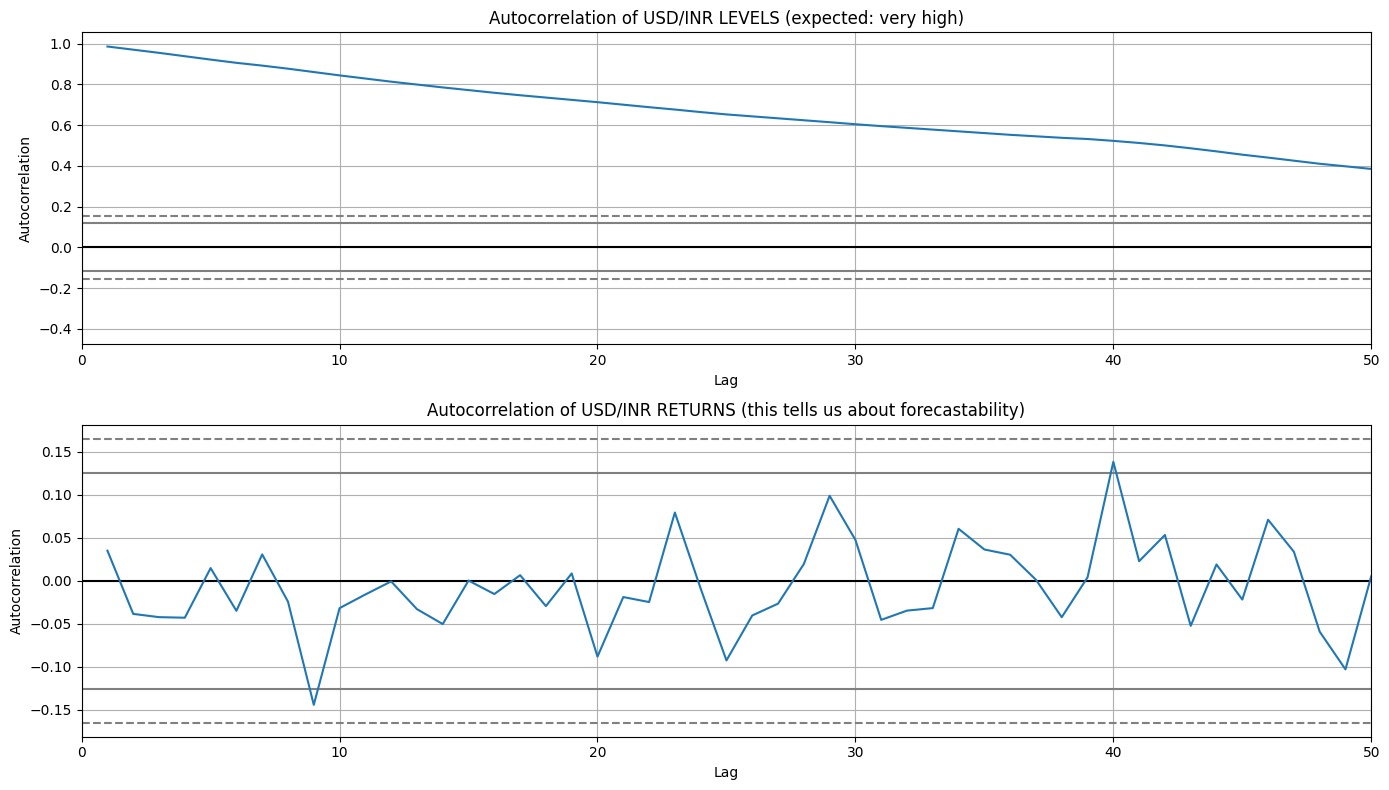


If the returns autocorrelation is mostly within the confidence bands,
past returns don't predict future returns — consistent with random walk.
This is the Meese-Rogoff finding in your data.


In [13]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Autocorrelation of LEVELS (will be very high — just means there's a trend)
pd.plotting.autocorrelation_plot(df['usd_inr'], ax=axes[0])
axes[0].set_title('Autocorrelation of USD/INR LEVELS (expected: very high)')
axes[0].set_xlim(0, 50)

# Autocorrelation of RETURNS (this is what matters for prediction)
pd.plotting.autocorrelation_plot(returns['usd_inr'], ax=axes[1])
axes[1].set_title('Autocorrelation of USD/INR RETURNS (this tells us about forecastability)')
axes[1].set_xlim(0, 50)

plt.tight_layout()
plt.savefig('fx_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nIf the returns autocorrelation is mostly within the confidence bands,")
print("past returns don't predict future returns — consistent with random walk.")
print("This is the Meese-Rogoff finding in your data.")

In [ ]:
# The baseline: tomorrow's rate = today's rate
# How well does this "model" do?

df_eval = df['usd_inr'].copy()
naive_forecast = df_eval.shift(1)  # yesterday's rate as today's forecast
actual = df_eval

errors = actual - naive_forecast
mae = errors.abs().mean()
rmse = (errors**2).mean()**0.5
mape = (errors.abs() / actual).mean() * 100

print("=== Naive Random Walk Baseline ===")
print(f"Forecast rule: tomorrow's rate = today's rate")
print(f"\nMean Absolute Error: {mae:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Percentage Error: {mape:.4f}%")
print(f"\nThis is your bar to beat. Any ML model must do better than this")
print(f"to be worth deploying. Spoiler: for FX, this is very hard.")